<a href="https://colab.research.google.com/github/hoapp07/PhuHoa_AI_UEH/blob/main/Hw2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

177.97619047619048


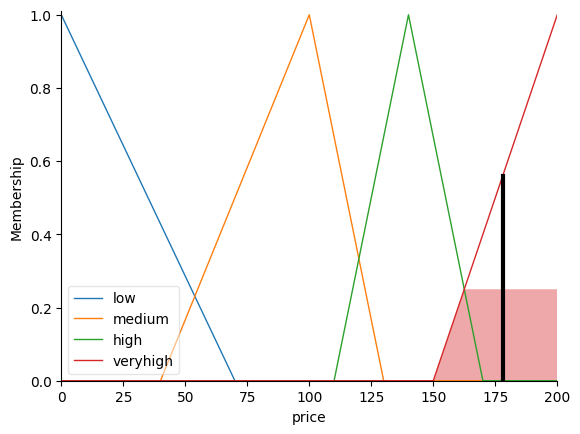

In [ ]:
#2.11
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
distance = ctrl.Antecedent(np.arange(0, 50.1, 0.1), 'distance')
distance['short']= fuzz.trimf(distance.universe, [0, 0, 3])
distance['medium']= fuzz.trimf(distance.universe, [2, 8, 8])
distance['long']= fuzz.trimf(distance.universe, [6, 20, 20])
distance['verylong'] = fuzz.trimf(distance.universe, [15, 50, 50])
traffic = ctrl.Antecedent(np.arange(0, 101, 1), 'traffic')
traffic['low']= fuzz.trimf(traffic.universe, [0, 0, 30])
traffic['medium']= fuzz.trimf(traffic.universe, [20, 50, 70])
traffic['high']= fuzz.trimf(traffic.universe, [60, 100, 100])
demand = ctrl.Antecedent(np.arange(0, 101, 1), 'demand')
demand['low']= fuzz.trimf(demand.universe, [0, 0, 30])
demand['medium']= fuzz.trimf(demand.universe, [20, 50, 70])
demand['high']= fuzz.trimf(demand.universe, [60, 100, 100])
weather = ctrl.Antecedent(np.arange(0, 10.1, 0.1), 'weather')
weather['good']= fuzz.trimf(weather.universe, [0, 0, 4])
weather['moderate']= fuzz.trimf(weather.universe, [3, 5, 7])
weather['bad']= fuzz.trimf(weather.universe, [6, 10, 10])
rating = ctrl.Antecedent(np.arange(1, 5.1, 0.1), 'rating')
rating['poor']= fuzz.trimf(rating.universe, [1, 1, 2.5])
rating['average']= fuzz.trimf(rating.universe, [2, 3, 4])
rating['good']= fuzz.trimf(rating.universe, [3.5, 5, 5])
punctuality = ctrl.Antecedent(np.arange(0, 101, 1), 'punctuality')
punctuality['late']= fuzz.trimf(punctuality.universe, [0, 0, 50])
punctuality['ontime']= fuzz.trimf(punctuality.universe, [40, 60, 80])
punctuality['early']= fuzz.trimf(punctuality.universe, [70, 100, 100])
price = ctrl.Consequent(np.arange(0, 201, 1), 'price')
price['low']= fuzz.trimf(price.universe, [0, 0, 70])
price['medium']= fuzz.trimf(price.universe, [40, 100, 130])
price['high']= fuzz.trimf(price.universe, [110, 140, 170])
price['veryhigh']= fuzz.trimf(price.universe, [150, 200, 200])
bonus = ctrl.Consequent(np.arange(0, 101, 1), 'bonus')
bonus['none']= fuzz.trimf(bonus.universe, [0, 0, 20])
bonus['few']= fuzz.trimf(bonus.universe, [10, 30, 45])
bonus['moderate']= fuzz.trimf(bonus.universe, [35, 55, 70])
bonus['high']= fuzz.trimf(bonus.universe, [65, 90, 100])
rule1= ctrl.Rule(distance['short'] & traffic['low'] & demand['low'], price['low'])
rule2= ctrl.Rule(distance['short'] & traffic['medium'] & demand['high'], price['medium'])
rule3= ctrl.Rule(distance['medium'] & traffic['high'] & demand['high'], price['high'])
rule4= ctrl.Rule(distance['long'] & traffic['medium'] & weather['good'], price['medium'])
rule5= ctrl.Rule(distance['long'] & traffic['high'] & weather['bad'], price['veryhigh'])
rule6= ctrl.Rule(distance['verylong'] & traffic['high'] & demand['high'], price['veryhigh'])
rule7= ctrl.Rule(distance['medium'] & traffic['low'] & demand['low'], price['medium'])
rule8= ctrl.Rule(distance['short'] & traffic['high'] & weather['bad'], price['high'])
rule9= ctrl.Rule(distance['verylong'] & weather['bad'], price['veryhigh'])
rule10= ctrl.Rule(distance['medium'] & traffic['medium'] & weather['moderate'], price['medium'])
price_ctrl= ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9, rule10])
price_sim= ctrl.ControlSystemSimulation(price_ctrl)
price_sim.input['distance']= 25
price_sim.input['traffic']= 80
price_sim.input['demand']= 70
price_sim.input['weather']= 7
price_sim.compute()
print(price_sim.output['price'])
price.view(sim=price_sim)

31.222222222222232


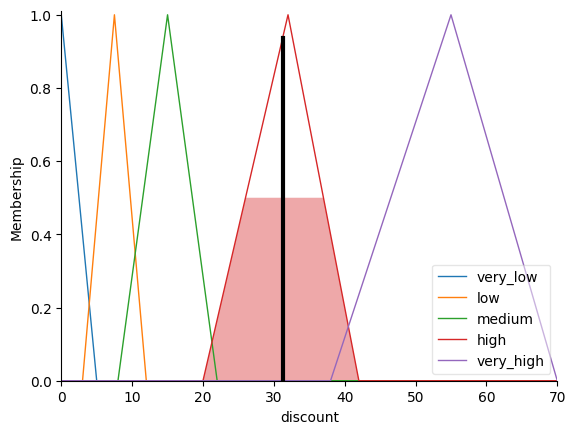

In [ ]:
#2.12
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
rating = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'rating')
rating['low']    = fuzz.trimf(rating.universe, [0, 0, 4.0])
rating['medium'] = fuzz.trimf(rating.universe, [3.9, 4.25, 4.6])
rating['high']   = fuzz.trimf(rating.universe, [4.4, 5, 5])
sales_vol = ctrl.Antecedent(np.arange(0, 101, 1), 'sales_vol')
sales_vol['low']    = fuzz.trimf(sales_vol.universe, [0, 0, 40])
sales_vol['medium'] = fuzz.trimf(sales_vol.universe, [30, 50, 70])
sales_vol['high']   = fuzz.trimf(sales_vol.universe, [60, 100, 100])
profit_margin = ctrl.Antecedent(np.arange(0, 101, 1), 'profit_margin')
profit_margin['low']    = fuzz.trimf(profit_margin.universe, [0, 20, 40])
profit_margin['medium'] = fuzz.trimf(profit_margin.universe, [35, 55, 75])
profit_margin['high']   = fuzz.trimf(profit_margin.universe, [70, 100, 100])
seasonal = ctrl.Antecedent(np.arange(0, 15, 1), 'seasonal')
seasonal['none']      = fuzz.trimf(seasonal.universe, [0, 0, 0])
seasonal['moderate']  = fuzz.trimf(seasonal.universe, [1, 5, 10])
seasonal['high']      = fuzz.trimf(seasonal.universe, [9, 15, 15])
competitor = ctrl.Antecedent(np.arange(0, 11, 1), 'competitor')
competitor['low']    = fuzz.trimf(competitor.universe, [0, 0, 4])
competitor['medium'] = fuzz.trimf(competitor.universe, [3, 5, 7])
competitor['high']   = fuzz.trimf(competitor.universe, [6, 9, 10])
discount = ctrl.Consequent(np.arange(0, 70.1, 0.1), 'discount')
discount['very_low']   = fuzz.trimf(discount.universe, [0, 0, 5])
discount['low']        = fuzz.trimf(discount.universe, [3, 7.5, 12])
discount['medium']     = fuzz.trimf(discount.universe, [8, 15, 22])
discount['high']       = fuzz.trimf(discount.universe, [20, 32, 42])
discount['very_high']  = fuzz.trimf(discount.universe, [38, 55, 70])
rule1 = ctrl.Rule(rating['high'] & sales_vol['high'] & profit_margin['high'], discount['very_low'])
rule2 = ctrl.Rule(rating['low'] & sales_vol['low'] & profit_margin['high'], discount['high'])
rule3 = ctrl.Rule(seasonal['high'] & competitor['high'], discount['high'])
rule4 = ctrl.Rule(rating['medium'] & sales_vol['medium'] & profit_margin['medium'], discount['medium'])
rule5 = ctrl.Rule(competitor['low'] & profit_margin['low'] & sales_vol['high'], discount['very_low'])
rule6 = ctrl.Rule(rating['low'] & seasonal['none'], discount['medium'])
rule7 = ctrl.Rule(sales_vol['low'] & profit_margin['low'], discount['very_high'])
discount_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7])
discount_sim = ctrl.ControlSystemSimulation(discount_ctrl)
discount_sim.input['rating'] = 4.3
discount_sim.input['sales_vol'] = 50
discount_sim.input['profit_margin'] = 20
discount_sim.input['seasonal'] = 12
discount_sim.input['competitor'] = 9
discount_sim.compute()
print(discount_sim.output['discount'])
discount.view(sim=discount_sim)

🎯 Tỷ lệ chiết khấu đề xuất: 20.00%


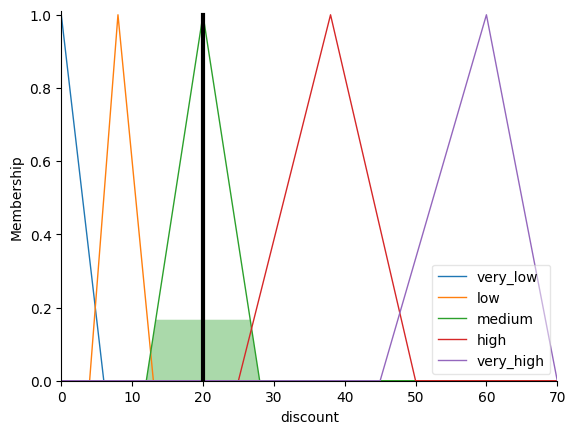

In [ ]:
#2.13
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
demand = ctrl.Antecedent(np.arange(0, 101, 1), 'demand')
demand['low']    = fuzz.trimf(demand.universe, [0, 0, 35])
demand['medium'] = fuzz.trimf(demand.universe, [25, 50, 75])
demand['high']   = fuzz.trimf(demand.universe, [65, 100, 100])
pressure = ctrl.Antecedent(np.arange(0, 101, 1), 'pressure')
pressure['low']    = fuzz.trimf(pressure.universe, [0, 0, 35])
pressure['medium'] = fuzz.trimf(pressure.universe, [25, 50, 75])
pressure['high']   = fuzz.trimf(pressure.universe, [65, 100, 100])
reputation = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'reputation')
reputation['low']    = fuzz.trimf(reputation.universe, [0, 0, 4.0])
reputation['medium'] = fuzz.trimf(reputation.universe, [3.8, 4.25, 4.7])
reputation['high']   = fuzz.trimf(reputation.universe, [4.3, 5, 5])
margin = ctrl.Antecedent(np.arange(0, 101, 1), 'margin')
margin['low']    = fuzz.trimf(margin.universe, [0, 0, 35])
margin['medium'] = fuzz.trimf(margin.universe, [25, 50, 75])
margin['high']   = fuzz.trimf(margin.universe, [65, 100, 100])
seasonal = ctrl.Antecedent(np.arange(0, 101, 1), 'seasonal')
seasonal['none']     = fuzz.trimf(seasonal.universe, [0, 0, 35])
seasonal['moderate'] = fuzz.trimf(seasonal.universe, [20, 60, 90])
seasonal['high']     = fuzz.trimf(seasonal.universe, [70, 100, 100])
discount = ctrl.Consequent(np.arange(0, 70.1, 0.1), 'discount')
discount['very_low']   = fuzz.trimf(discount.universe, [0, 0, 6])
discount['low']        = fuzz.trimf(discount.universe, [4, 8, 13])
discount['medium']     = fuzz.trimf(discount.universe, [12, 20, 28])
discount['high']       = fuzz.trimf(discount.universe, [25, 38, 50])
discount['very_high']  = fuzz.trimf(discount.universe, [45, 60, 70])
rule1 = ctrl.Rule(demand['high'] & pressure['low'] & margin['low'], discount['very_low'])
rule2 = ctrl.Rule(demand['low'] & pressure['high'] & margin['high'], discount['high'])
rule3 = ctrl.Rule(reputation['high'] & margin['medium'] & seasonal['high'], discount['medium'])
rule4 = ctrl.Rule(pressure['high'] & seasonal['high'] & margin['high'], discount['very_high'])
rule5 = ctrl.Rule(reputation['low'] & demand['medium'] & margin['low'], discount['medium'])
rule6 = ctrl.Rule(demand['high'] & seasonal['none'] & pressure['low'], discount['very_low'])
rule7 = ctrl.Rule(margin['high'] & pressure['medium'] & seasonal['moderate'], discount['medium'])
system = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7])
sim = ctrl.ControlSystemSimulation(system)
sim.input['demand'] = 85
sim.input['pressure'] = 50
sim.input['reputation'] = 4.2
sim.input['margin'] = 75
sim.input['seasonal'] = 85     # Cao
sim.compute()
result = sim.output['discount']
print(f" Tỷ lệ chiết khấu đề xuất: {result:.2f}%")
discount.view(sim=sim)

 Số lượng đơn hàng cần kết hợp: 84.5 (Nhiều)
 Ưu tiên giao hàng: 50.0 (Trung bình)


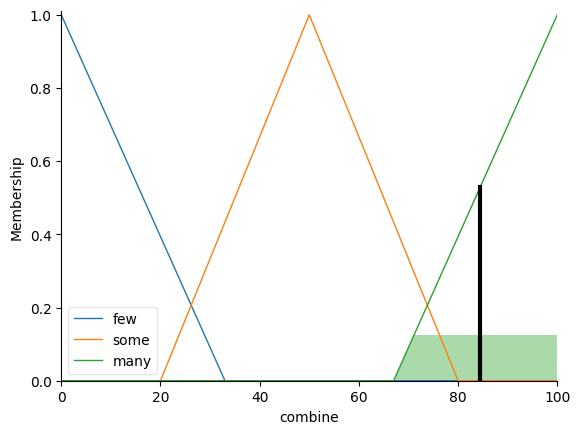

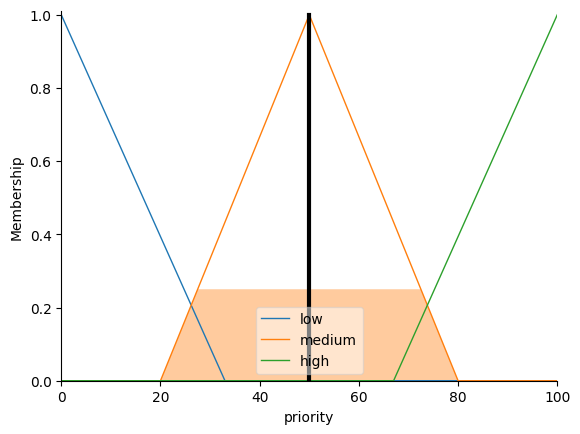

In [25]:
#2.14
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
order_density = ctrl.Antecedent(np.arange(0, 101, 1), 'order_density')
order_density['low']    = fuzz.trimf(order_density.universe, [0, 0, 40])
order_density['medium'] = fuzz.trimf(order_density.universe, [30, 50, 70])
order_density['high']   = fuzz.trimf(order_density.universe, [60, 100, 100])
urgency = ctrl.Antecedent(np.arange(0, 101, 1), 'urgency')
urgency['low']    = fuzz.trimf(urgency.universe, [0, 0, 40])
urgency['medium'] = fuzz.trimf(urgency.universe, [30, 50, 70])
urgency['high']   = fuzz.trimf(urgency.universe, [60, 100, 100])
driver_load = ctrl.Antecedent(np.arange(0, 101, 1), 'driver_load')
driver_load['low']    = fuzz.trimf(driver_load.universe, [0, 0, 40])
driver_load['medium'] = fuzz.trimf(driver_load.universe, [30, 50, 70])
driver_load['high']   = fuzz.trimf(driver_load.universe, [60, 100, 100])
traffic = ctrl.Antecedent(np.arange(0, 101, 1), 'traffic')
traffic['low']    = fuzz.trimf(traffic.universe, [0, 0, 40])
traffic['medium'] = fuzz.trimf(traffic.universe, [30, 50, 70])
traffic['high']   = fuzz.trimf(traffic.universe, [60, 100, 100])
profit = ctrl.Antecedent(np.arange(0, 101, 1), 'profit')
profit['low']    = fuzz.trimf(profit.universe, [0, 0, 40])
profit['medium'] = fuzz.trimf(profit.universe, [30, 50, 70])
profit['high']   = fuzz.trimf(profit.universe, [60, 100, 100])

combine = ctrl.Consequent(np.arange(0, 101, 1), 'combine')
combine['few']       = fuzz.trimf(combine.universe, [0, 0, 33])
combine['some']      = fuzz.trimf(combine.universe, [20, 50, 80])
combine['many']      = fuzz.trimf(combine.universe, [67, 100, 100])
priority = ctrl.Consequent(np.arange(0, 101, 1), 'priority')
priority['low']      = fuzz.trimf(priority.universe, [0, 0, 33])
priority['medium']   = fuzz.trimf(priority.universe, [20, 50, 80])
priority['high']     = fuzz.trimf(priority.universe, [67, 100, 100])
# LUẬT CHO KẾT HỢP ĐƠN HÀNG
rule1 = ctrl.Rule(order_density['high'] & driver_load['low'] & traffic['low'], combine['many'])
rule2 = ctrl.Rule(order_density['medium'] & traffic['high'] & urgency['medium'], combine['some'])
rule3 = ctrl.Rule(driver_load['high'] & order_density['high'] & profit['medium'], combine['some'])
rule4 = ctrl.Rule(order_density['low'] & urgency['high'] & traffic['medium'], combine['some'])
rule5 = ctrl.Rule(profit['high'] & urgency['high'] & traffic['high'], combine['some'])
# LUẬT CHO ƯU TIÊN GIAO HÀNG
rule6 = ctrl.Rule(urgency['high'] & profit['high'], priority['high'])
rule7 = ctrl.Rule(urgency['medium'] & traffic['medium'], priority['medium'])
rule8 = ctrl.Rule(urgency['low'] & order_density['high'] & profit['low'], priority['low'])

system = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8])
sim = ctrl.ControlSystemSimulation(system)
sim.input['order_density'] = 85
sim.input['urgency'] = 50
sim.input['driver_load'] = 20
sim.input['traffic'] = 35
sim.input['profit'] = 50
sim.compute()
combine_result = sim.output['combine']
priority_result = sim.output['priority']
if combine_result < 33:
    combine_label = "Ít"
elif combine_result < 67:
    combine_label = "Một số"
else:
    combine_label = "Nhiều"

if priority_result < 33:
    priority_label = "Thấp"
elif priority_result < 67:
    priority_label = "Trung bình"
else:
    priority_label = "Cao"
print(f" Số lượng đơn hàng cần kết hợp: {combine_result:.1f} ({combine_label})")
print(f" Ưu tiên giao hàng: {priority_result:.1f} ({priority_label})")
combine.view(sim=sim)
priority.view(sim=sim)


In [ ]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 12.2 MB/s eta 0:00:00
